In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df = pd.read_csv('clean_titanic.csv')
df.head()
df.shape

(891, 11)

Modeling

Until now you prepared the data.

Now the goal becomes:

Train models to learn patterns from the data

train_test_split
from sklearn.model_selection import train_test_split

VERY important.

This is used to split data into:

| Part                | Purpose                           |
| ------------------- | --------------------------------- |
| Training set        | Model learns from this            |
| Validation/Test set | Model is evaluated on unseen data |


Why Split Data?

Because if you train and test on SAME data:

Model may just memorize

That gives fake high accuracy.

We want:

Generalization

Meaning:

Can model perform well on unseen data?
Real-Life Analogy

Think of exams.

In [2]:
X = df.drop('Survived', axis=1)
y = df['Survived']

print("Features:", X.columns.tolist())
print("X shape:", X.shape)
print("y value counts:\n", y.value_counts())

Features: ['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'FamilySize', 'Has_Cabin', 'IsAlone', 'Title', 'AgeBand']
X shape: (891, 10)
y value counts:
 Survived
0    549
1    342
Name: count, dtype: int64


In [3]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape[0])
print("Val size:", X_val.shape[0])

Train size: 712
Val size: 179


The BIG Picture

You just created:

A fair learning environment
Training Set

Used for:

Learning patterns
Validation Set

Used for:

Testing understanding on unseen data
Core ML Workflow So Far
Clean Data
↓
Separate X and y
↓
Split train/validation
↓
Train model
↓
Predict on validation
↓
Measure performance

In [5]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_val)
print("Logistic Regression accuracy:", round(accuracy_score(y_val, y_pred_lr), 4))
print(classification_report(y_val, y_pred_lr))

Logistic Regression accuracy: 0.7877
              precision    recall  f1-score   support

           0       0.82      0.84      0.83       110
           1       0.73      0.71      0.72        69

    accuracy                           0.79       179
   macro avg       0.78      0.77      0.77       179
weighted avg       0.79      0.79      0.79       179



Logistic Regression
from sklearn.linear_model import LogisticRegression

This imports the model.

Despite the name:

Logistic Regression is mainly used for Classification

especially binary classification like:

| Problem | Classes         |
| ------- | --------------- |
| Titanic | survived / died |
| Spam    | spam / not spam |
| Disease | yes / no        |

How Logistic Regression Thinks

Very simplified idea:

It calculates probability.

Example:

Passenger survival probability = 0.83

Then converts probability into class.

VERY Important ML Insight

Accuracy tells:

“How often model was correct”

BUT NOT:

what mistakes it made
which class it struggles with
whether imbalance affects results

That’s why we use more metrics too.

BIG ML Concept You Just Learned

You completed the full first modeling pipeline:

Train model
↓
Learn patterns
↓
Predict unseen data
↓
Measure performance

That is the heart of supervised ML.

In [7]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_val)
print("Decision Tree accuracy:", round(accuracy_score(y_val, y_pred_dt), 4))

Decision Tree accuracy: 0.8101


Decision Tree

A Decision Tree learns by asking a series of questions.

Example:

Is passenger female?
    YES → likely survive
    NO →
        Is age < 10?
            YES → survive
            NO → die

So unlike Logistic Regression (which uses equations/probabilities), Decision Trees learn:

Rule-based decisions

Train Model
dt.fit(X_train, y_train)

Tree learns decision rules from training data.

Predict
y_pred_dt = dt.predict(X_val)

Uses learned rules on unseen validation data.

Accuracy
accuracy_score(y_val, y_pred_dt)

Checks prediction correctness on validation set.

MOST Important Concept Here → Overfitting

If tree grows too deep:

Model memorizes instead of learning

| Good Model      | Overfit Model        |
| --------------- | -------------------- |
| learns patterns | memorizes noise      |
| generalizes     | fails on unseen data |


In [9]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_val)
print("Random Forest accuracy:", round(accuracy_score(y_val, y_pred_rf), 4))

Random Forest accuracy: 0.8268


Random Forest

Random Forest is basically:

Many Decision Trees combined together

Instead of trusting ONE tree:

Use many trees and take majority vote

-----------------------

n_estimators=100

Means:

Build 100 different decision trees

Each tree learns slightly differently.

Final prediction = majority voting.

max_depth=6

Limits tree depth again to reduce overfitting.

| Model         | Behavior             |
| ------------- | -------------------- |
| Decision Tree | one person's opinion |
| Random Forest | crowd decision       |


In [10]:
results = {
    'Logistic Regression': accuracy_score(y_val, y_pred_lr),
    'Decision Tree':       accuracy_score(y_val, y_pred_dt),
    'Random Forest':       accuracy_score(y_val, y_pred_rf),
}
for name, acc in sorted(results.items(), key=lambda x: -x[1]):
    print(f"{name:25s} {acc:.4f}")

Random Forest             0.8268
Decision Tree             0.8101
Logistic Regression       0.7877


Main ML Concept Here

You are now doing:

Model Comparison

Instead of assuming a model is best, you:

train multiple models
evaluate fairly
compare performance

This is standard ML workflow.

----------

Important Insight

Highest accuracy is not ALWAYS best.

Later you'll also compare:

precision
recall
F1-score
training speed
interpretability
overfitting

But accuracy is the first simple comparison metric.

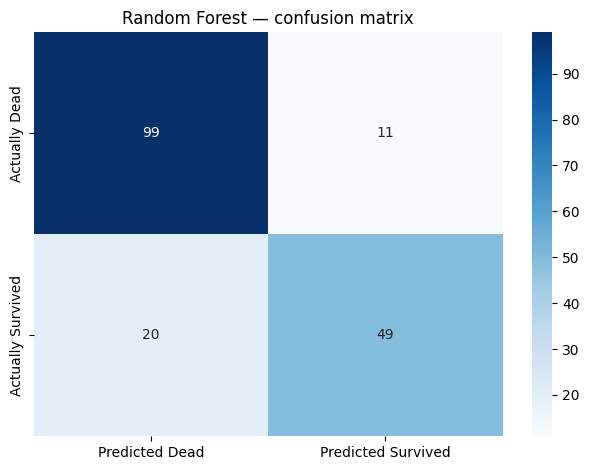

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_val, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Dead','Predicted Survived'],
            yticklabels=['Actually Dead','Actually Survived'])
plt.title('Random Forest — confusion matrix')
plt.tight_layout()
plt.show()

Confusion Matrix

Accuracy only tells:

“How many predictions were correct?”

But it does NOT tell:

“What mistakes did the model make?”

That’s why we use:

Confusion Matrix

---

Quick Summary

Confusion Matrix:

compares actual vs predicted classes
shows exact types of errors
helps understand model behavior beyond accuracy

Key terms:

TP = correct survived
TN = correct dead
FP = predicted survive wrongly
FN = predicted dead wrongly

Main concept:

Good ML evaluation means understanding model mistakes, not just accuracy

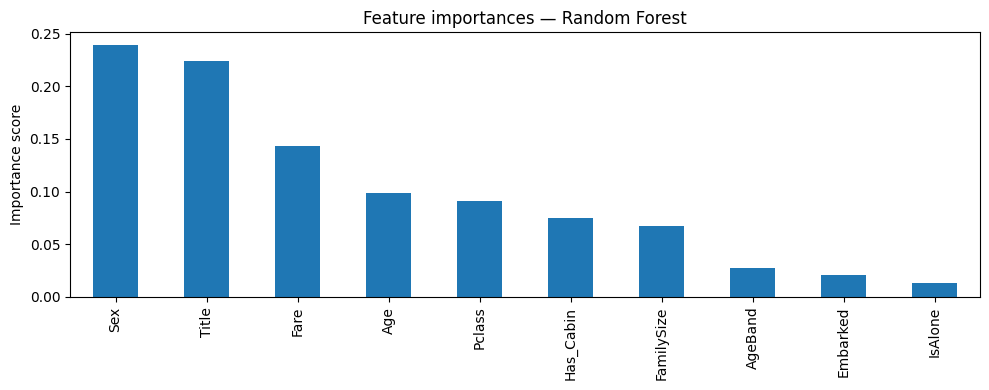

Sex           0.239240
Title         0.223596
Fare          0.143723
Age           0.098336
Pclass        0.090861
Has_Cabin     0.075324
FamilySize    0.067454
AgeBand       0.027566
Embarked      0.020461
IsAlone       0.013440
dtype: float64


In [12]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

importances.plot(kind='bar', figsize=(10, 4))
plt.title('Feature importances — Random Forest')
plt.ylabel('Importance score')
plt.tight_layout()
plt.show()

print(importances)

MOST Important Insight

Now you can validate your intuition.

Earlier during EDA you guessed:

women survive more
class matters
family matters

Feature importance checks whether the model also found those patterns useful.

---

Quick Summary

Feature importance:

.measures how useful each feature was
.helps interpret model behavior
.validates EDA + feature engineering

Main concept:

Better features → better learning → better predictions